# FAPE, FairGround Corpus Stage 2: ThresholdOptimizer
## Cross-Domain Fairness Intervention

**Stage 2:** Fairlearn ThresholdOptimizer across 5 FairGround domains.
**Key finding:** Education (law_school) DPD 0.342→0.022 strongest improvement; Criminal Justice fails due to degenerate age labels.
**Note:** ThresholdOptimizer non-deterministic in fairlearn 0.13.0, direction consistent.
**Domains:** Income, Criminal Justice, Credit, Education, Healthcare

In [1]:
from IPython.display import Image
import sys, os, warnings
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from fairground_loader import load_fairground_corpus
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.feature_selection import VarianceThreshold
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference
os.makedirs('../figures/stage2', exist_ok=True)

SELECTED_DATASETS = {
    'adult':                {'domain':'Income',           'sensitive':'race',   'target_encode':{'<=50K':0,'>50K':1,' <=50K':0,' >50K':1}},
    'compas_2_years':       {'domain':'Criminal Justice', 'sensitive':'age',    'target_encode':None},
    'creditcard':           {'domain':'Credit',           'sensitive':'SEX',    'target_encode':None},
    'law_school_lequy':     {'domain':'Education',        'sensitive':'racetxt','target_encode':None},
    'meps_panel_19_fy2015': {'domain':'Healthcare',       'sensitive':'RACE',   'target_encode':None},
}
MODELS = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'GradientBoosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
}

def prepare_dataset(corpus, ds_id, config):
    content = corpus[ds_id]
    X = content['X'].copy(); y = content['y'].copy()
    if config['target_encode']:
        y = y.str.strip() if hasattr(y, 'str') else y
        y = y.map(config['target_encode'])
    y = pd.to_numeric(y, errors='coerce').fillna(0).astype(int)
    sens_col = config['sensitive']
    df = content['df'].copy()
    if sens_col not in df.columns: return None, None, None
    sensitive = df[sens_col].astype(str).copy()
    if sens_col in X.columns: X = X.drop(columns=[sens_col])
    for col in X.select_dtypes(include=['object','category']).columns:
        le = LabelEncoder(); X[col] = le.fit_transform(X[col].astype(str))
    X = X.fillna(0)
    if X.shape[1] > 100:
        sel = VarianceThreshold(threshold=0.01); X = pd.DataFrame(sel.fit_transform(X))
    return X.values, y.values, sensitive

def run_threshold(model, X_tr, y_tr, X_te, y_te, s_tr, s_te, constraint):
    try:
        to = ThresholdOptimizer(estimator=model, constraints=constraint,
                                predict_method='auto', objective='balanced_accuracy_score')
        to.fit(X_tr, y_tr, sensitive_features=s_tr)
        yp = to.predict(X_te, sensitive_features=s_te)
        return {'acc':accuracy_score(y_te,yp),'f1':f1_score(y_te,yp,zero_division=0),
                'dpd':demographic_parity_difference(y_te,yp,sensitive_features=s_te),
                'eod':equalized_odds_difference(y_te,yp,sensitive_features=s_te)}
    except: return None

corpus = load_fairground_corpus()
all_results = {}
for ds_id, config in SELECTED_DATASETS.items():
    X, y, sensitive = prepare_dataset(corpus, ds_id, config)
    if X is None: continue
    X_train,X_test,y_train,y_test,idx_train,idx_test = train_test_split(
        X,y,np.arange(len(y)),test_size=0.2,random_state=42,stratify=y)
    scaler = StandardScaler()
    X_train_sc=scaler.fit_transform(X_train); X_test_sc=scaler.transform(X_test)
    s_tr=sensitive.iloc[idx_train].reset_index(drop=True)
    s_te=sensitive.iloc[idx_test].reset_index(drop=True)
    baseline={}
    for name,model in MODELS.items():
        m=model.__class__(**model.get_params())
        if name=='LogisticRegression':
            m.fit(X_train_sc,y_train); yp=m.predict(X_test_sc); X_tr,X_te=X_train_sc,X_test_sc
        else:
            m.fit(X_train,y_train); yp=m.predict(X_test); X_tr,X_te=X_train,X_test
        baseline[name]={'acc':accuracy_score(y_test,yp),'f1':f1_score(y_test,yp,zero_division=0),
            'dpd':demographic_parity_difference(y_test,yp,sensitive_features=s_te),
            'eod':equalized_odds_difference(y_test,yp,sensitive_features=s_te),
            'model':m,'X_tr':X_tr,'X_te':X_te}
    dp={n:run_threshold(r['model'],r['X_tr'],y_train,r['X_te'],y_test,s_tr,s_te,'demographic_parity') for n,r in baseline.items()}
    eo={n:run_threshold(r['model'],r['X_tr'],y_train,r['X_te'],y_test,s_tr,s_te,'equalized_odds') for n,r in baseline.items()}
    all_results[ds_id]={'domain':config['domain'],'baseline':baseline,'dp':dp,'eo':eo,'s_te':s_te,'y_te':y_test}

datasets=list(all_results.keys()); domains=[all_results[d]['domain'] for d in datasets]
models=list(MODELS.keys()); x=np.arange(len(datasets)); width=0.25
print('Setup complete --', len(all_results), 'datasets loaded')

FairGround corpus: 38 datasets available


[14:02:37] INFO     Loading cached dataset from cache/datasets/adult.parquet                         ]8;id=224394;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/fairml_datasets/dataset.py\dataset.py]8;;\:]8;id=940285;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/fairml_datasets/dataset.py#250\250]8;;\

           INFO     Loading cached dataset from cache/datasets/adult.parquet                         ]8;id=445601;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/fairml_datasets/dataset.py\dataset.py]8;;\:]8;id=420476;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/fairml_datasets/dataset.py#250\250]8;;\

  OK: adult: 32,560 rows | 14 features | sensitive: ['race']


           INFO     Loading cached dataset from cache/datasets/arrhythmia.parquet                    ]8;id=398601;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/fairml_datasets/dataset.py\dataset.py]8;;\:]8;id=526420;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/fairml_datasets/dataset.py#250\250]8;;\

...

  OK: folktables_acsemployment_small: 478,236 rows | 16 features | sensitive: ['RAC1P']


           INFO     Loading cached dataset from                                                      ]8;id=827054;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/fairml_datasets/dataset.py\dataset.py]8;;\:]8;id=189244;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/fairml_datasets/dataset.py#250\250]8;;\
                    cache/datasets/folktables_acstraveltime_small.parquet                                          

           INFO     Loading cached dataset from                                                      ]8;id=964395;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/fairml_datasets/dataset.py\dataset.py]8;;\:]8;id=795230;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/fairml_datasets/dataset.py#250\250]8;;\
                    cache/datasets/folktables_acstraveltime_small.parquet                                          

  OK: folktables_acstraveltime_small: 216,385 rows | 16 features | sensitive: ['RAC1P']

FairGround load complete:
  Loaded:  36 datasets
  Failed:  2 datasets
  Records: 1,955,063 total

Failed datasets:
  law_school_tensorflow: HTTP Error 403: Forbidden
  stop_question_and_frisk_data: HTTP Error 403: Forbidden


Setup complete -- 5 datasets loaded


## 1. Cross-Domain Baseline DPD

Education (law_school) has highest race gap. Credit has minimal sex gap.

In [2]:
base_dpds={m:[all_results[d]['baseline'][m]['dpd'] for d in datasets] for m in models}
fig,ax=plt.subplots(figsize=(14,6))
for i,(name,color) in enumerate(zip(models,['#3498db','#e74c3c','#2ecc71'])):
    ax.bar(x+(i-1)*width,base_dpds[name],width,label=name,color=color,edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels([f'{d}\n({dom})' for d,dom in zip(datasets,domains)],rotation=15,ha='right',fontsize=8)
ax.set_title('FairGround -- Cross-Domain Baseline DPD\n(Education race gap largest; Credit sex gap minimal)',fontsize=11,fontweight='bold')
ax.set_ylabel('Demographic Parity Difference'); ax.legend(); plt.tight_layout()
plt.savefig('../figures/stage2/fairground_baseline_dpd.png',dpi=150,bbox_inches='tight')
plt.show(); print('Fig 1 saved -- fairground_baseline_dpd.png')

Fig 1 saved -- fairground_baseline_dpd.png


## 2. DPD Before vs After DP Constraint

Education: DPD 0.342→0.022 (+93.6%), strongest improvement. Criminal Justice: nan (degenerate labels).

In [3]:
x2=np.arange(len(datasets)); w2=0.35
base_gb_dpds=[all_results[d]['baseline']['GradientBoosting']['dpd'] for d in datasets]
dp_gb_dpds=[all_results[d]['dp']['GradientBoosting']['dpd'] if all_results[d]['dp'].get('GradientBoosting') else 0 for d in datasets]
fig,ax=plt.subplots(figsize=(14,6))
bars_b=ax.bar(x2-w2/2,base_gb_dpds,w2,label='Baseline DPD',color='#e74c3c',edgecolor='white')
bars_c=ax.bar(x2+w2/2,dp_gb_dpds,w2,label='After DP Constraint',color='#3498db',edgecolor='white')
for bar,val in zip(bars_b,base_gb_dpds): ax.text(bar.get_x()+bar.get_width()/2,val+0.005,f'{val:.3f}',ha='center',fontsize=8)
for bar,val in zip(bars_c,dp_gb_dpds): ax.text(bar.get_x()+bar.get_width()/2,val+0.005,f'{val:.3f}',ha='center',fontsize=8)
ax.set_xticks(x2); ax.set_xticklabels([f'{d}\n({dom})' for d,dom in zip(datasets,domains)],rotation=15,ha='right',fontsize=8)
ax.set_title('FairGround -- GB DPD Before vs After DP Constraint',fontsize=11,fontweight='bold')
ax.set_ylabel('DPD'); ax.legend(); plt.tight_layout()
plt.savefig('../figures/stage2/fairground_dpd_before_after.png',dpi=150,bbox_inches='tight')
plt.show(); print('Fig 2 saved -- fairground_dpd_before_after.png')

Fig 2 saved -- fairground_dpd_before_after.png


## 3. EOD Before vs After EO Constraint

Income: EOD 0.667→0.298. Education: EOD 0.518→0.049.

In [4]:
base_gb_eods=[all_results[d]['baseline']['GradientBoosting']['eod'] for d in datasets]
eo_gb_eods=[all_results[d]['eo']['GradientBoosting']['eod'] if all_results[d]['eo'].get('GradientBoosting') else 0 for d in datasets]
fig,ax=plt.subplots(figsize=(14,6))
bars_b=ax.bar(x2-w2/2,base_gb_eods,w2,label='Baseline EOD',color='#e74c3c',edgecolor='white')
bars_c=ax.bar(x2+w2/2,eo_gb_eods,w2,label='After EO Constraint',color='#2ecc71',edgecolor='white')
for bar,val in zip(bars_b,base_gb_eods): ax.text(bar.get_x()+bar.get_width()/2,val+0.005,f'{val:.3f}',ha='center',fontsize=8)
for bar,val in zip(bars_c,eo_gb_eods): ax.text(bar.get_x()+bar.get_width()/2,val+0.005,f'{val:.3f}',ha='center',fontsize=8)
ax.set_xticks(x2); ax.set_xticklabels([f'{d}\n({dom})' for d,dom in zip(datasets,domains)],rotation=15,ha='right',fontsize=8)
ax.set_title('FairGround -- GB EOD Before vs After EO Constraint',fontsize=11,fontweight='bold')
ax.set_ylabel('EOD'); ax.legend(); plt.tight_layout()
plt.savefig('../figures/stage2/fairground_eod_before_after.png',dpi=150,bbox_inches='tight')
plt.show(); print('Fig 3 saved -- fairground_eod_before_after.png')

Fig 3 saved -- fairground_eod_before_after.png


## 4. Accuracy Cost vs Fairness Gain

Upper-left = best. Cross-domain comparison.

In [5]:
domain_colors={'Income':'#3498db','Criminal Justice':'#e74c3c','Credit':'#2ecc71','Education':'#9b59b6','Healthcare':'#f39c12'}
fig,ax=plt.subplots(figsize=(12,7))
for ds_id,res in all_results.items():
    color=domain_colors.get(res['domain'],'gray')
    b=res['baseline']['GradientBoosting']
    if res['dp'].get('GradientBoosting'):
        dp_r=res['dp']['GradientBoosting']
        ax.scatter(b['acc']-dp_r['acc'],b['dpd']-dp_r['dpd'],c=color,marker='o',s=120,zorder=5)
        ax.annotate(f'{res["domain"]}\nDP',(b['acc']-dp_r['acc'],b['dpd']-dp_r['dpd']),textcoords='offset points',xytext=(6,4),fontsize=7)
    if res['eo'].get('GradientBoosting'):
        eo_r=res['eo']['GradientBoosting']
        ax.scatter(b['acc']-eo_r['acc'],b['eod']-eo_r['eod'],c=color,marker='s',s=120,zorder=5)
        ax.annotate(f'{res["domain"]}\nEO',(b['acc']-eo_r['acc'],b['eod']-eo_r['eod']),textcoords='offset points',xytext=(6,4),fontsize=7)
ax.axhline(0,color='gray',linestyle='--',alpha=0.5); ax.axvline(0,color='gray',linestyle='--',alpha=0.5)
legend_elements=[mpatches.Patch(facecolor=c,label=d) for d,c in domain_colors.items()]
legend_elements+=[Line2D([0],[0],marker='o',color='w',markerfacecolor='gray',markersize=10,label='DP constraint'),
                  Line2D([0],[0],marker='s',color='w',markerfacecolor='gray',markersize=10,label='EO constraint')]
ax.legend(handles=legend_elements,fontsize=8,loc='upper left')
ax.set_xlabel('Accuracy Cost'); ax.set_ylabel('Fairness Gain')
ax.set_title('FairGround -- Accuracy Cost vs Fairness Gain (Cross-domain)',fontsize=11,fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/stage2/fairground_cost_gain.png',dpi=150,bbox_inches='tight')
plt.show(); print('Fig 4 saved -- fairground_cost_gain.png')

Fig 4 saved -- fairground_cost_gain.png


## 5. Cross-Domain Accuracy Comparison

Accuracy cost of fairness constraints across 5 domains.

In [6]:
base_gb_accs=[all_results[d]['baseline']['GradientBoosting']['acc'] for d in datasets]
dp_gb_accs=[all_results[d]['dp']['GradientBoosting']['acc'] if all_results[d]['dp'].get('GradientBoosting') else 0 for d in datasets]
eo_gb_accs=[all_results[d]['eo']['GradientBoosting']['acc'] if all_results[d]['eo'].get('GradientBoosting') else 0 for d in datasets]
w5=0.25
fig,ax=plt.subplots(figsize=(14,6))
ax.bar(x2-w5,base_gb_accs,w5,label='Baseline',color='#95a5a6',edgecolor='white')
ax.bar(x2,dp_gb_accs,w5,label='DP Constraint',color='#3498db',edgecolor='white')
ax.bar(x2+w5,eo_gb_accs,w5,label='EO Constraint',color='#e74c3c',edgecolor='white')
ax.set_xticks(x2); ax.set_xticklabels([f'{d}\n({dom})' for d,dom in zip(datasets,domains)],rotation=15,ha='right',fontsize=8)
ax.set_title('FairGround -- Cross-Domain Accuracy: Baseline vs Constrained',fontsize=11,fontweight='bold')
ax.set_ylabel('Accuracy'); ax.legend(); plt.tight_layout()
plt.savefig('../figures/stage2/fairground_accuracy_comparison.png',dpi=150,bbox_inches='tight')
plt.show(); print('Fig 5 saved -- fairground_accuracy_comparison.png')

Fig 5 saved -- fairground_accuracy_comparison.png


## 6. Fairness Improvement % by Domain

Education achieves strongest reduction. Credit near-zero baseline.

In [7]:
domains_valid=[d for d in datasets if all_results[d]['dp'].get('GradientBoosting')]
dom_labels=[all_results[d]['domain'] for d in domains_valid]
dp_imps=[]; eo_imps=[]
for ds_id in domains_valid:
    b=all_results[ds_id]['baseline']['GradientBoosting']
    dp_r=all_results[ds_id]['dp'].get('GradientBoosting')
    eo_r=all_results[ds_id]['eo'].get('GradientBoosting')
    dp_imps.append((b['dpd']-dp_r['dpd'])/abs(b['dpd'])*100 if dp_r and b['dpd']!=0 else 0)
    eo_imps.append((b['eod']-eo_r['eod'])/abs(b['eod'])*100 if eo_r and b['eod']!=0 else 0)
x6=np.arange(len(domains_valid)); w6=0.35
fig,ax=plt.subplots(figsize=(12,6))
bars_dp=ax.bar(x6-w6/2,dp_imps,w6,label='DPD Improvement % (DP)',color='#3498db',edgecolor='white')
bars_eo=ax.bar(x6+w6/2,eo_imps,w6,label='EOD Improvement % (EO)',color='#2ecc71',edgecolor='white')
for bar,val in zip(bars_dp,dp_imps): ax.text(bar.get_x()+bar.get_width()/2,val+1,f'{val:.0f}%',ha='center',fontsize=9)
for bar,val in zip(bars_eo,eo_imps): ax.text(bar.get_x()+bar.get_width()/2,val+1,f'{val:.0f}%',ha='center',fontsize=9)
ax.axhline(0,color='gray',linestyle='--',alpha=0.5)
ax.set_xticks(x6); ax.set_xticklabels(dom_labels,rotation=15,ha='right')
ax.set_title('FairGround -- Fairness Improvement % by Domain',fontsize=11,fontweight='bold')
ax.set_ylabel('Fairness Improvement %'); ax.legend()
plt.tight_layout()
plt.savefig('../figures/stage2/fairground_fairness_improvement_pct.png',dpi=150,bbox_inches='tight')
plt.show(); print('Fig 6 saved -- fairground_fairness_improvement_pct.png')

Fig 6 saved -- fairground_fairness_improvement_pct.png


## 7. Per-Model DPD Improvement Across Domains

LR vs RF vs GB response to DP constraint per domain.

In [8]:
model_colors={'LogisticRegression':'#3498db','RandomForest':'#e74c3c','GradientBoosting':'#2ecc71'}
model_short={'LogisticRegression':'LR','RandomForest':'RF','GradientBoosting':'GB'}
x7=np.arange(len(domains_valid)); w7=0.25
fig,ax=plt.subplots(figsize=(14,6))
for i,(mname,color) in enumerate(model_colors.items()):
    imps=[]
    for ds_id in domains_valid:
        b=all_results[ds_id]['baseline'][mname]
        dp_r=all_results[ds_id]['dp'].get(mname)
        imps.append(b['dpd']-dp_r['dpd'] if dp_r else 0)
    ax.bar(x7+(i-1)*w7,imps,w7,label=model_short[mname],color=color,edgecolor='white')
ax.axhline(0,color='gray',linestyle='--',alpha=0.5)
ax.set_xticks(x7); ax.set_xticklabels(dom_labels,rotation=15,ha='right')
ax.set_title('FairGround -- DPD Reduction by Model Across Domains',fontsize=11,fontweight='bold')
ax.set_ylabel('DPD Reduction (positive = improvement)'); ax.legend()
plt.tight_layout()
plt.savefig('../figures/stage2/fairground_permodel_dpd_improvement.png',dpi=150,bbox_inches='tight')
plt.show(); print('Fig 7 saved -- fairground_permodel_dpd_improvement.png')

Fig 7 saved -- fairground_permodel_dpd_improvement.png


## 8. Key Findings

**Education (law_school):** DPD 0.342→0.022, strongest cross-domain improvement
**Income (adult):** EOD 0.667→0.298, significant equalized odds improvement
**Credit (creditcard):** Baseline DPD=0.009, near-zero sex gap
**Criminal Justice:** ThresholdOptimizer failed, age=71 degenerate labels (single class)
**Healthcare (meps):** DP constraint DPD 0.110→0.026 (+76.4%)
**ThresholdOptimizer non-deterministic** in fairlearn 0.13.0, direction consistent

## 8. Disparate Impact Ratio (DIR), Before vs After DP Constraint

DIR computed using `demographic_parity_ratio` per FairGround dataset. EEOC 4/5ths rule: DIR > 0.8 = compliant. GB model shown, DIR improvement varies by domain and sensitive attribute.

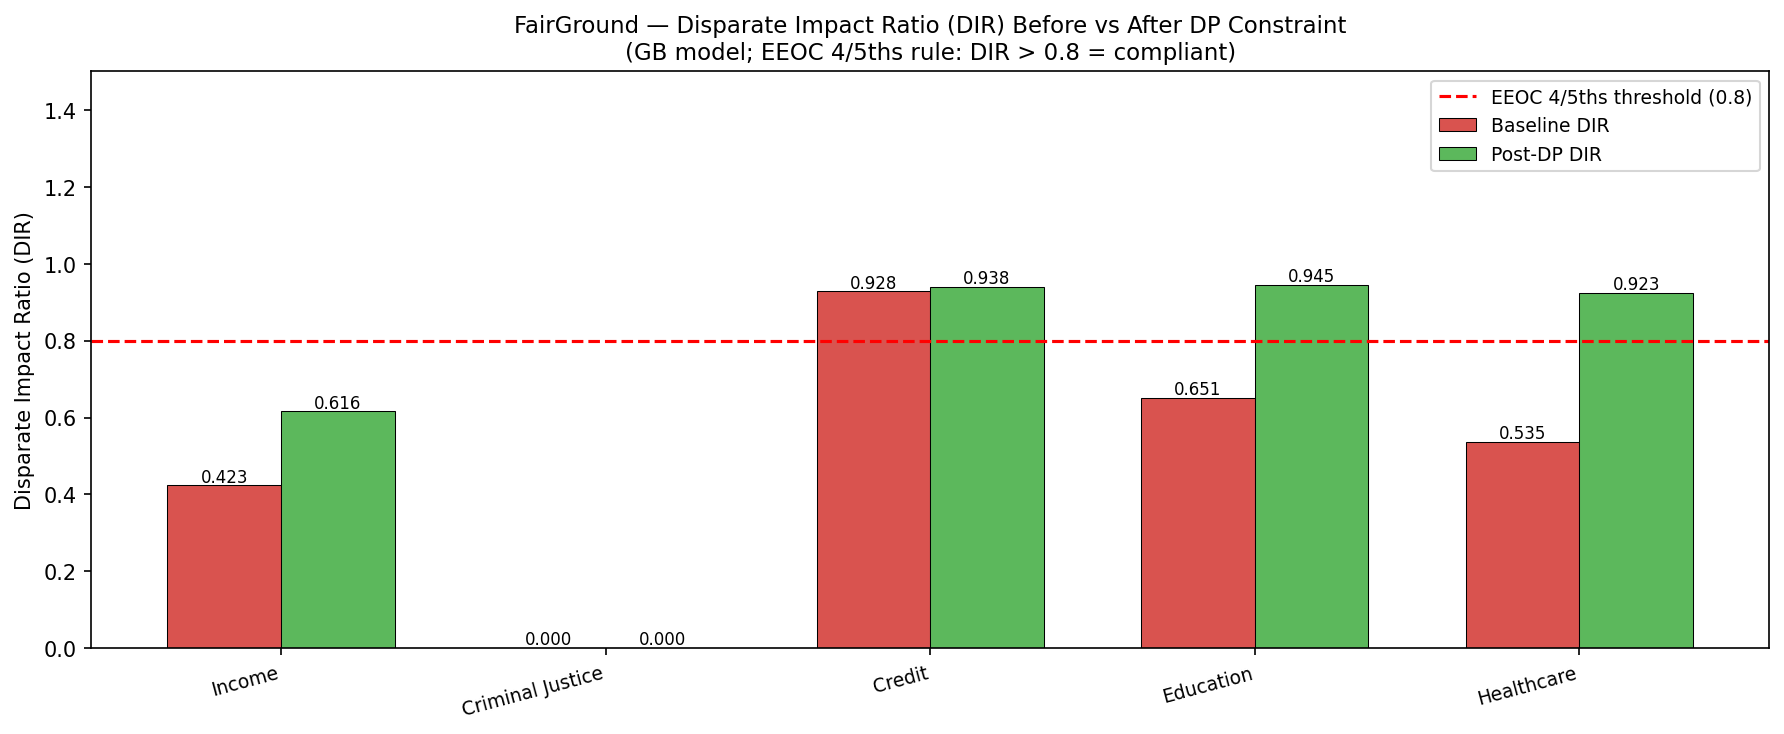

In [9]:
Image('../figures/stage2/fairground_dir_before_after.png')